## Exercise 5

In [76]:
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from cookiedisaster.envs import CookieDisasterEnv

#### Task 2
##### Linear Q-function and Feature Design

In this part, we approximate the Q-function using a linear model instead of a Q-table. The idea is to represent each state-action pair with a feature vector and compute:

Q(s, a) = wᵀ φ(s, a)

where φ(s, a) contains useful information about the state and action, and w are the weights we learn.

The features include:
- robot position and velocity
- cookie position and remaining time
- distance between robot and cookie
- simple non-linear terms like velocity²
- indicators for whether the robot is moving toward or away from the cookie

We use **action-specific features**, meaning each action has its own set of weights. This allows the model to learn different behaviors for moving left, right, or staying still.

Feature engineering is important here because a linear model cannot learn complex relationships on its own, so we provide useful signals manually.

In [77]:
ACTIONS = [0, 1, 2]   # env actions: left, stay, right

class LinearQAgent:
    def __init__(self, alpha=0.01, gamma=0.99, epsilon=0.1):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

        self.n_actions = 3
        self.n_base_features = 10
        self.n_features = self.n_actions * self.n_base_features

        self.w = np.zeros(self.n_features, dtype=np.float32)

    def unpack_state(self, obs):
        x = obs["agent"]["pos"]
        v = obs["agent"]["vel"]
        c = obs["cookie"]["pos"]
        t = obs["cookie"]["time"]
        return x, v, c, t

    def base_features(self, obs):
        x, v, c, t = self.unpack_state(obs)

        # normalization
        x_n = x / 10.0
        c_n = c / 10.0
        t_n = t / 5.0

        # choose a rough velocity scale for normalization
        v_scale = 5.0
        v_n = np.clip(v / v_scale, -2.0, 2.0)

        d = c - x
        d_n = d / 10.0
        abs_d_n = abs(d) / 10.0
        sign_d = np.sign(d)

        moving_toward = 1.0 if d * v > 0 else 0.0
        moving_away = 1.0 if d * v < 0 else 0.0

        return np.array([
            1.0,            # bias
            x_n,
            c_n,
            t_n,
            v_n,
            d_n,
            abs_d_n,
            v_n ** 2,
            moving_toward,
            moving_away,
        ], dtype=np.float32)

    def phi(self, obs, action):
        base = self.base_features(obs)
        features = np.zeros(self.n_features, dtype=np.float32)
        start = action * self.n_base_features
        end = start + self.n_base_features
        features[start:end] = base
        return features

    def q_value(self, obs, action):
        return np.dot(self.w, self.phi(obs, action))

    def best_action(self, obs):
        q_vals = [self.q_value(obs, a) for a in ACTIONS]
        return int(np.argmax(q_vals))

    def select_action(self, obs):
        if np.random.rand() < self.epsilon:
            return np.random.choice(ACTIONS)
        return self.best_action(obs)

    def update(self, obs, action, reward, next_obs, done):
        q_sa = self.q_value(obs, action)

        if done:
            target = reward
        else:
            target = reward + self.gamma * max(self.q_value(next_obs, a) for a in ACTIONS)

        td_error = target - q_sa
        self.w += self.alpha * td_error * self.phi(obs, action)

        return td_error

##### Q-learning with Linear Function Approximation

We train the agent using Q-learning with a linear approximation of the Q-function. Instead of updating a table, we update the weight vector w using the temporal-difference (TD) error.

At each step, we:
1. Select an action using an ε-greedy policy (random exploration + best known action)
2. Take a step in the environment
3. Compute the TD target:

   target = r + γ max_a' Q(s', a')

4. Update the weights:

   w ← w + α (target - Q(s, a)) φ(s, a)

This allows the agent to gradually learn which actions lead to higher rewards.

Since the task is continuing, we train over fixed-length episodes. Over time, the agent learns to move toward cookies efficiently while controlling its speed to avoid penalties.

In [78]:
env = CookieDisasterEnv(render_mode=None)
agent = LinearQAgent(alpha=0.01, gamma=0.99, epsilon=0.2)

num_episodes = 500
max_steps = 200

returns = []

for ep in range(num_episodes):
    obs, info = env.reset()
    total_reward = 0.0

    for step in range(max_steps):
        action = agent.select_action(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated
        agent.update(obs, action, reward, next_obs, done)

        obs = next_obs
        total_reward += reward

        if done:
            break

    returns.append(total_reward)

    # epsilon decay
    agent.epsilon = max(0.02, agent.epsilon * 0.995)

    if (ep + 1) % 50 == 0:
        avg_ret = np.mean(returns[-50:])
        print(f"Episode {ep+1}, avg return (last 50): {avg_ret:.3f}")

env.close()

Episode 50, avg return (last 50): 3.021
Episode 100, avg return (last 50): 9.377
Episode 150, avg return (last 50): 9.921
Episode 200, avg return (last 50): 9.396
Episode 250, avg return (last 50): 10.444
Episode 300, avg return (last 50): 10.764
Episode 350, avg return (last 50): 12.282
Episode 400, avg return (last 50): 10.599
Episode 450, avg return (last 50): 11.494
Episode 500, avg return (last 50): 11.407


#### Task 3

State preprocessing:

In [79]:
def extract_features(obs: dict) -> np.ndarray:
    x = obs["agent"]["pos"]
    v = obs["agent"]["vel"]
    c = obs["cookie"]["pos"]
    t = obs["cookie"]["time"]

    delta     = c - x                       # signed gap
    abs_delta = abs(delta)
    urgency   = delta / (t + 1e-6)         # how fast to close the gap
    v_sq      = v ** 2

    phi = np.array([
        x / 10.0,                           # normalised position
        np.clip(v, -20, 20) / 20.0,         # normalised velocity
        c / 10.0,                           # normalised cookie pos
        np.clip(t,  0,  5) /  5.0,         # normalised time
        np.clip(delta,    -10, 10) / 10.0,  # signed distance
        np.clip(abs_delta, 0, 10) / 10.0,   # absolute distance
        np.clip(urgency,  -10, 10) / 10.0,  # urgency
        np.clip(v_sq, 0, 400)    / 400.0,   # KE proxy
        ], dtype=np.float32)
    return phi

NN:

In [80]:
class QNetwork(nn.Module):
    """
    Fully-connected network that maps φ(s) → Q(s, a) for all 3 actions.

    Architecture
    ------------
    Input  : 8 features
    Hidden : 64 → 64  (ReLU activations)
    Output : 3 Q-values  (one per action: accelerate left / none / right)

    Two hidden layers are sufficient here because the feature engineering
    already handles the nonlinear work (distance, urgency).  Batch
    normalisation is intentionally omitted — it complicates target
    network updates and the state space is small.
    """
    def __init__(self, n_features: int = 8, n_actions: int = 3,
                 hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [81]:
class ReplayBuffer:
    """
    Uniform experience replay buffer (FIFO).

    Stores (φ(s), a, r, φ(s'), done) tuples.
    Breaks temporal correlations in the gradient stream,
    which stabilises training significantly.
    """
    def __init__(self, capacity: int = 50_000):
        self.buf = deque(maxlen=capacity)

    def push(self, phi, a, r, phi_next, done):
        self.buf.append((phi, a, r, phi_next, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buf, batch_size)
        phi, a, r, phi_next, done = zip(*batch)
        return (
            torch.FloatTensor(np.array(phi)),
            torch.LongTensor(a),
            torch.FloatTensor(r),
            torch.FloatTensor(np.array(phi_next)),
            torch.FloatTensor(done),
        )

    def __len__(self):
        return len(self.buf)

agent:

In [82]:
class DQNAgent:

    def __init__(
        self,
        n_features: int = 8,
        n_actions:  int = 3,
        lr:         float = 3e-4,
        gamma:      float = 0.95,
        eps_start:  float = 1.0,
        eps_end:    float = 0.05,
        eps_decay:  float = 0.995,
        batch_size: int   = 64,
        buf_size:   int   = 50_000,
        target_sync:int   = 200,
    ):
        self.n_actions   = n_actions
        self.gamma       = gamma
        self.eps         = eps_start
        self.eps_end     = eps_end
        self.eps_decay   = eps_decay
        self.batch_size  = batch_size
        self.target_sync = target_sync
        self.steps       = 0

        self.q      = QNetwork(n_features, n_actions)
        self.q_targ = QNetwork(n_features, n_actions)
        self.q_targ.load_state_dict(self.q.state_dict())
        self.q_targ.eval()

        self.opt    = optim.Adam(self.q.parameters(), lr=lr)
        self.buf    = ReplayBuffer(buf_size)

    # ── action selection ──────────────────────────────────────────────
    def act(self, phi: np.ndarray) -> int:
        """ε-greedy policy."""
        if random.random() < self.eps:
            return random.randrange(self.n_actions)
        with torch.no_grad():
            q_vals = self.q(torch.FloatTensor(phi).unsqueeze(0))
        return int(q_vals.argmax())

    # ── learning step ─────────────────────────────────────────────────
    def update(self) -> float | None:
        """
        One gradient update from a sampled mini-batch.
        Returns the scalar loss (for logging), or None if buffer not warm.
        """
        if len(self.buf) < self.batch_size:
            return None

        phi, a, r, phi_next, done = self.buf.sample(self.batch_size)

        # Current Q-values for chosen actions
        q_vals = self.q(phi).gather(1, a.unsqueeze(1)).squeeze(1)

        # TD target using frozen target network
        with torch.no_grad():
            q_next     = self.q_targ(phi_next).max(1).values
            td_targets = r + self.gamma * q_next * (1 - done)

        loss = nn.functional.smooth_l1_loss(q_vals, td_targets)  # Huber

        self.opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.q.parameters(), 1.0)       # grad clip
        self.opt.step()

        # Sync target network periodically
        self.steps += 1
        if self.steps % self.target_sync == 0:
            self.q_targ.load_state_dict(self.q.state_dict())

        # Decay ε
        self.eps = max(self.eps_end, self.eps * self.eps_decay)

        return float(loss)

    def store(self, phi, a, r, phi_next, done):
        self.buf.push(phi, a, r, phi_next, done)

Training code:

In [83]:
def train(env, n_episodes: int = 800, max_steps: int = 200,
          render: bool = False):

    agent = DQNAgent()
    returns_hist = []
    loss_hist  = []

    for ep in range(n_episodes):
        obs, _ = env.reset()
        phi  = extract_features(obs)

        ep_return = 0.0
        ep_losses = []

        for _ in range(max_steps):
            a   = agent.act(phi)
            obs_next, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated

            phi_next = extract_features(obs_next)
            agent.store(phi, a, r, phi_next, float(done))

            loss = agent.update()
            if loss is not None:
                ep_losses.append(loss)

            phi = phi_next
            ep_return += r

            if done:
                break

        returns_hist.append(ep_return)
        loss_hist.append(np.mean(ep_losses) if ep_losses else float("nan"))

        if ep % 100 == 0:
            avg = np.mean(returns_hist[-100:])
            print(f"Ep {ep:4d}  return={ep_return:7.2f}  "
                  f"avg100={avg:7.2f}  ε={agent.eps:.3f}  "
                  f"loss={loss_hist[-1]:.4f}")

    return agent, returns_hist, loss_hist

In [84]:
def plot_training(returns_hist, loss_hist, window: int = 50):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # --- Returns ---
    ax = axes[0]
    ax.plot(returns_hist, alpha=0.3, color="steelblue", label="Per-episode")
    smoothed = np.convolve(returns_hist,
                           np.ones(window) / window, mode="valid")
    ax.plot(range(window - 1, len(returns_hist)),
            smoothed, color="steelblue", label=f"{window}-ep avg")
    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Cumulative return")
    ax.set_title("Training returns")
    ax.legend()

    # --- Loss ---
    ax = axes[1]
    valid = [(i, l) for i, l in enumerate(loss_hist) if not np.isnan(l)]
    if valid:
        xs, ys = zip(*valid)
        ax.plot(xs, ys, alpha=0.4, color="coral")
        if len(ys) >= window:
            smooth = np.convolve(ys, np.ones(window) / window, mode="valid")
            ax.plot(xs[window - 1:], smooth, color="coral",
                    label=f"{window}-ep avg")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Huber loss")
    ax.set_title("TD loss")
    ax.legend()

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()
    print("Saved training_curves.png")

In [85]:
def evaluate(env, agent: DQNAgent, n_episodes: int = 20,
             render: bool = False) -> float:
    """Run the greedy policy (ε=0) and return mean return."""
    agent.eps = 0.0
    returns   = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        ep_return = 0.0
        for _ in range(1000):
            phi = extract_features(obs)
            a   = agent.act(phi)
            obs, r, terminated, truncated, _ = env.step(a)
            ep_return += r
            if terminated or truncated:
                break
        returns.append(ep_return)
    mean_r = float(np.mean(returns))
    print(f"Greedy evaluation ({n_episodes} eps): mean return = {mean_r:.2f}")
    return mean_r

Training DQN on CookieDisasterEnv
Ep    0  return=  -7.39  avg100=  -7.39  ε=0.503  loss=0.0365
Ep  100  return=  28.00  avg100=  16.42  ε=0.050  loss=0.0131
Ep  200  return=  22.74  avg100=  22.70  ε=0.050  loss=0.0118
Ep  300  return=  22.44  avg100=  23.91  ε=0.050  loss=0.0123
Ep  400  return=  20.87  avg100=  23.23  ε=0.050  loss=0.0132
Ep  500  return=  21.84  avg100=  23.52  ε=0.050  loss=0.0137
Ep  600  return=  27.61  avg100=  23.51  ε=0.050  loss=0.0117
Ep  700  return=  26.39  avg100=  23.86  ε=0.050  loss=0.0140


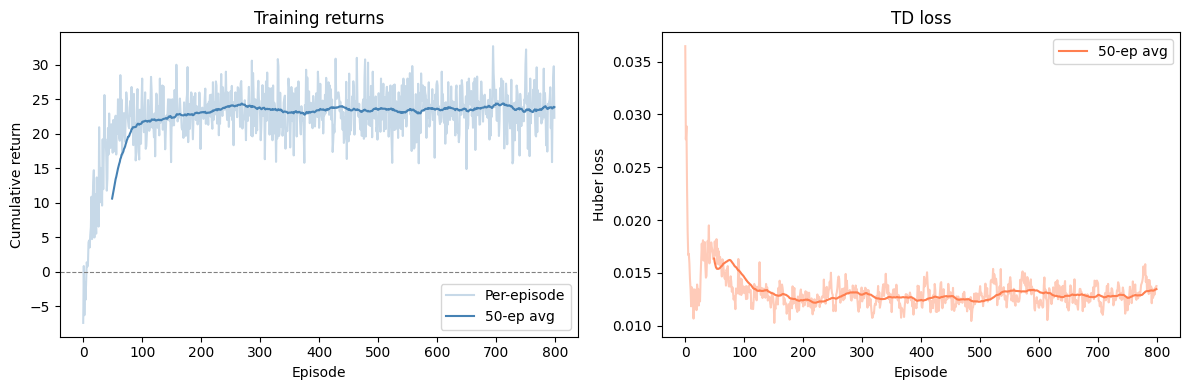

Saved training_curves.png
Greedy evaluation (20 eps): mean return = 136.39


In [86]:
env = CookieDisasterEnv(render_mode=None)

print("=" * 60)
print("Training DQN on CookieDisasterEnv")
print("=" * 60)
agent, returns_hist, loss_hist = train(env, n_episodes=800)

plot_training(returns_hist, loss_hist)
evaluate(env, agent, n_episodes=20)
env.close()

#### Task 4

The linear model achieved higher performance, with average returns around $10$--$12$, while the neural network only reached approximately $3$ after the same amount of training.

The linear approximation performed better due to its simplicity and stability. With designed features, it was able to capture most of the relevant structure of the environment and learn efficiently from limited data.

In contrast, the neural network, although more expressive, was harder to train. The combination of Q-learning and function approximation leads to unstable targets, and without additional techniques such as replay buffers or target networks, learning is slower and less effective.

This shows that a simpler model can outperform a more complex one when training stability and data efficiency are important.


#### Task 5

Small neural network for the actor:
This outputs action probabilities.

##### Actor-Critic Model

In this part, we use two neural networks. The actor learns the policy directly by outputting probabilities for each action, while the critic learns the value of the current state. The actor decides what to do, and the critic evaluates how good the situation is.

In [87]:
class ActorCriticNet(nn.Module):
    """
    Shared torso + two heads:
    - actor head  -> policy logits over 3 actions
    - critic head -> scalar value V(s)
    """
    def __init__(self, n_features: int = 8, n_actions: int = 3, hidden: int = 64):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )

        self.policy_head = nn.Linear(hidden, n_actions)
        self.value_head = nn.Linear(hidden, 1)

    def forward(self, x: torch.Tensor):
        z = self.shared(x)
        logits = self.policy_head(z)
        value = self.value_head(z).squeeze(-1)
        return logits, value

agent

In [88]:
class ActorCriticAgent:
    def __init__(
        self,
        n_features: int = 8,
        n_actions: int = 3,
        lr: float = 3e-4,
        gamma: float = 0.99,
        entropy_coef: float = 0.01,
        critic_coef: float = 0.5,
        grad_clip: float = 1.0,
        device: str = "cpu",
    ):
        self.gamma = gamma
        self.entropy_coef = entropy_coef
        self.critic_coef = critic_coef
        self.grad_clip = grad_clip
        self.device = torch.device(device)

        self.net = ActorCriticNet(
            n_features=n_features,
            n_actions=n_actions,
            hidden=64
        ).to(self.device)

        self.opt = optim.Adam(self.net.parameters(), lr=lr)

    def act(self, phi: np.ndarray):
        """
        Sample an action from π(a|s).
        Returns:
            action, log_prob, value, entropy
        """
        x = torch.tensor(phi, dtype=torch.float32, device=self.device).unsqueeze(0)
        logits, value = self.net(x)

        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        entropy = dist.entropy()

        return int(action.item()), log_prob, value.squeeze(0), entropy.squeeze(0)

    def greedy_act(self, phi: np.ndarray) -> int:
        """
        Greedy action for evaluation.
        """
        x = torch.tensor(phi, dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            logits, _ = self.net(x)
            action = torch.argmax(logits, dim=1)
        return int(action.item())

    def update(self, phi, reward, phi_next, terminated, log_prob, value, entropy):
        """
        One-step actor-critic update using TD(0):
            δ = r + γV(s') - V(s)
        """
        x_next = torch.tensor(phi_next, dtype=torch.float32, device=self.device).unsqueeze(0)

        with torch.no_grad():
            _, next_value = self.net(x_next)
            next_value = next_value.squeeze(0)
            target = torch.tensor(reward, dtype=torch.float32, device=self.device)
            if not terminated:
                target = target + self.gamma * next_value

        advantage = target - value

        actor_loss = -(log_prob * advantage.detach())
        critic_loss = advantage.pow(2)
        entropy_bonus = entropy

        loss = actor_loss + self.critic_coef * critic_loss - self.entropy_coef * entropy_bonus

        self.opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.net.parameters(), self.grad_clip)
        self.opt.step()

        return (
            float(loss.item()),
            float(actor_loss.item()),
            float(critic_loss.item()),
            float(advantage.item())
        )

actor critic agent

training loop:

In [89]:
def train_actor_critic(
    env,
    n_episodes: int = 800,
    max_steps: int = 200,
    render: bool = False,
):
    """
    Because CookieDisasterEnv is effectively continuing,
    we use fixed-length episodes for training.
    """
    agent = ActorCriticAgent()

    returns_hist = []
    loss_hist = []
    actor_loss_hist = []
    critic_loss_hist = []

    for ep in range(n_episodes):
        obs, _ = env.reset()
        phi = extract_features(obs)

        ep_return = 0.0
        ep_losses = []
        ep_actor_losses = []
        ep_critic_losses = []

        for _ in range(max_steps):
            action, log_prob, value, entropy = agent.act(phi)

            obs_next, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated   # probably always False in this env

            phi_next = extract_features(obs_next)

            loss, a_loss, c_loss, adv = agent.update(
                phi=phi,
                reward=reward,
                phi_next=phi_next,
                terminated=done,
                log_prob=log_prob,
                value=value,
                entropy=entropy,
            )

            ep_losses.append(loss)
            ep_actor_losses.append(a_loss)
            ep_critic_losses.append(c_loss)

            phi = phi_next
            ep_return += reward

            if done:
                break

        returns_hist.append(ep_return)
        loss_hist.append(np.mean(ep_losses))
        actor_loss_hist.append(np.mean(ep_actor_losses))
        critic_loss_hist.append(np.mean(ep_critic_losses))

        if ep % 100 == 0:
            avg100 = np.mean(returns_hist[-100:])
            print(
                f"Ep {ep:4d} | return={ep_return:8.2f} | "
                f"avg100={avg100:8.2f} | "
                f"loss={loss_hist[-1]:.4f} | "
                f"actor={actor_loss_hist[-1]:.4f} | "
                f"critic={critic_loss_hist[-1]:.4f}"
            )

    return agent, returns_hist, loss_hist, actor_loss_hist, critic_loss_hist



In [90]:
def evaluate_actor_critic(env, agent, n_episodes: int = 20, max_steps: int = 200):
    returns = []

    for _ in range(n_episodes):
        obs, _ = env.reset()
        ep_return = 0.0

        for _ in range(max_steps):
            phi = extract_features(obs)
            action = agent.greedy_act(phi)
            obs, reward, terminated, truncated, _ = env.step(action)
            ep_return += reward

            if terminated or truncated:
                break

        returns.append(ep_return)

    mean_return = float(np.mean(returns))
    std_return = float(np.std(returns))
    print(f"Greedy evaluation over {n_episodes} episodes: "
          f"mean return = {mean_return:.2f} ± {std_return:.2f}")
    return mean_return, std_return


In [91]:
def plot_training(returns_hist, loss_hist, actor_loss_hist, critic_loss_hist, window: int = 50):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Returns
    ax = axes[0]
    ax.plot(returns_hist, alpha=0.3, label="episode return")
    if len(returns_hist) >= window:
        smooth = np.convolve(returns_hist, np.ones(window) / window, mode="valid")
        ax.plot(range(window - 1, len(returns_hist)), smooth, label=f"{window}-ep avg")
    ax.set_title("Training returns")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Return")
    ax.legend()

    # Total loss
    ax = axes[1]
    ax.plot(loss_hist, alpha=0.5, label="total loss")
    if len(loss_hist) >= window:
        smooth = np.convolve(loss_hist, np.ones(window) / window, mode="valid")
        ax.plot(range(window - 1, len(loss_hist)), smooth, label=f"{window}-ep avg")
    ax.set_title("Total loss")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Loss")
    ax.legend()

    # Actor / critic losses
    ax = axes[2]
    ax.plot(actor_loss_hist, alpha=0.6, label="actor")
    ax.plot(critic_loss_hist, alpha=0.6, label="critic")
    ax.set_title("Actor vs critic losses")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Loss")
    ax.legend()

    plt.tight_layout()
    plt.savefig("actor_critic_training.png", dpi=150)
    plt.show()
    print("Saved actor_critic_training.png")

Training Actor-Critic on CookieDisasterEnv
Ep    0 | return=   -5.75 | avg100=   -5.75 | loss=0.0051 | actor=-0.0299 | critic=0.0917
Ep  100 | return=    3.60 | avg100=    5.95 | loss=0.0547 | actor=0.0199 | critic=0.0786
Ep  200 | return=    2.40 | avg100=    8.02 | loss=0.1371 | actor=0.0105 | critic=0.2594
Ep  300 | return=   18.89 | avg100=   10.17 | loss=0.0768 | actor=0.0220 | critic=0.1142
Ep  400 | return=    3.23 | avg100=   10.15 | loss=0.0315 | actor=-0.0491 | critic=0.1641
Ep  500 | return=   19.99 | avg100=   11.58 | loss=0.0579 | actor=-0.0028 | critic=0.1263
Ep  600 | return=   15.40 | avg100=   12.94 | loss=0.0812 | actor=-0.0133 | critic=0.1937
Ep  700 | return=   13.38 | avg100=   15.82 | loss=0.0272 | actor=-0.0237 | critic=0.1062


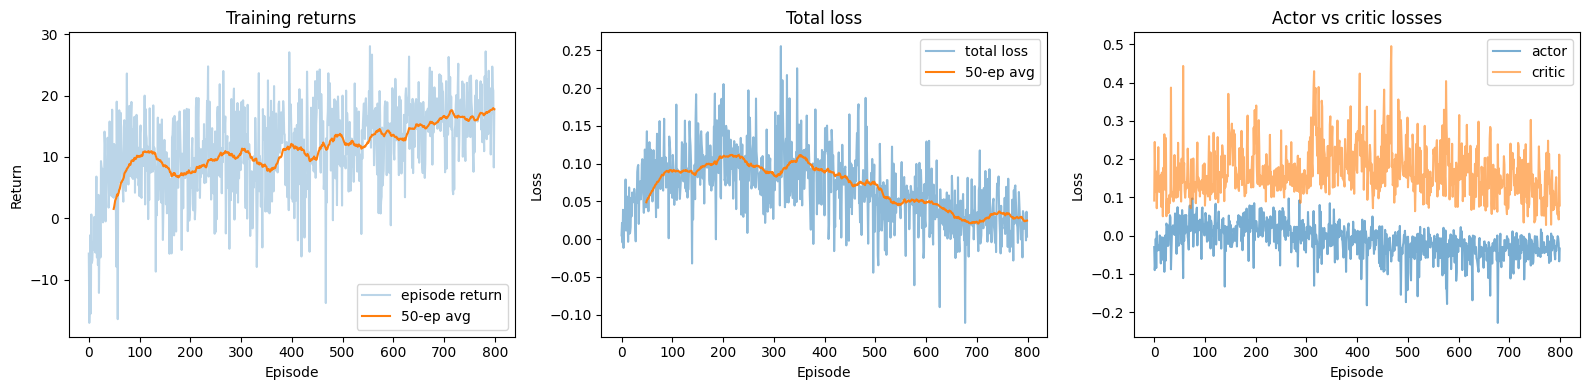

Saved actor_critic_training.png
Greedy evaluation over 20 episodes: mean return = 101.86 ± 6.35


In [92]:
env = CookieDisasterEnv(render_mode=None)

print("=" * 60)
print("Training Actor-Critic on CookieDisasterEnv")
print("=" * 60)

agent, returns_hist, loss_hist, actor_loss_hist, critic_loss_hist = train_actor_critic(
    env,
    n_episodes=800
)

plot_training(returns_hist, loss_hist, actor_loss_hist, critic_loss_hist)
evaluate_actor_critic(env, agent, n_episodes=20, max_steps=1000)

env.close()